## Лабораторная 6. BFS на GPU

- BFS ориентированного графа на cpu;
- BFS ориентированного графа на gpu через cuda;
- Сравнение времени работы реализаций на случайных графах и на реальных графах с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/).

*PS: запуск работы проводился в [Google Colab](https://colab.research.google.com/) в среде с графическим ускорителем T4.*

In [1]:
!pip install -q scipy pandas matplotlib numba python-graphblas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.0/353.0 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 14.0 MB/s eta 0:00:00


In [2]:
import time
import os
import glob
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from numba import cuda

In [3]:
import graphblas as gb

gb.init("suitesparse", blocking=False)

from graphblas.io import mmread

In [4]:
plt.style.use("default")
np.random.seed(0)

GPU_AVAILABLE = cuda.is_available()

print("graphblas:", gb.__version__)
print(f"GPU available: {GPU_AVAILABLE}")

graphblas: 2025.2.0
GPU available: True


In [5]:
import warnings
warnings.filterwarnings("ignore")

---

### BFS на CPU

In [6]:
def bfs_cpu(A, start):
    dist = np.full(A.shape[0], -1, dtype=np.int32)

    queue = [int(start)]
    head = 0
    dist[start] = 0

    while head < len(queue):
        v = queue[head]
        head += 1

        for pos in range(A.indptr[v], A.indptr[v + 1]):
            to = A.indices[pos]
            if dist[to] == -1:
                dist[to] = dist[v] + 1
                queue.append(int(to))

    return dist

### BFS на GPU

In [7]:
@cuda.jit
def bfs_kernel(indptr, indices, frontier, frontier_size, next_frontier, next_size, dist, level):
    tid = cuda.grid(1)

    if tid >= frontier_size[0]:
        return

    v = frontier[tid]
    start = indptr[v]
    end = indptr[v + 1]

    for pos in range(start, end):
        to = indices[pos]

        # atomic cas ставит расстояние только если вершина еще не посещена
        old = cuda.atomic.cas(dist, to, -1, level)
        if old == -1:
            place = cuda.atomic.add(next_size, 0, 1)
            next_frontier[place] = to


def bfs_gpu(A, start, threads_per_block=128):
    if not cuda.is_available():
        raise RuntimeError("gpu runtime не включен")

    n = A.shape[0]

    indptr = A.indptr.astype(np.int32)
    indices = A.indices.astype(np.int32)

    dist = np.full(n, -1, dtype=np.int32)
    dist[start] = 0

    frontier = np.full(n, -1, dtype=np.int32)
    frontier[0] = start
    next_frontier = np.full(n, -1, dtype=np.int32)

    d_indptr = cuda.to_device(indptr)
    d_indices = cuda.to_device(indices)
    d_dist = cuda.to_device(dist)
    d_frontier = cuda.to_device(frontier)
    d_next_frontier = cuda.to_device(next_frontier)
    d_frontier_size = cuda.to_device(np.array([1], dtype=np.int32))
    d_next_size = cuda.to_device(np.array([0], dtype=np.int32))

    frontier_size = 1
    level = 1

    while frontier_size > 0:
        d_next_size.copy_to_device(np.array([0], dtype=np.int32))

        blocks = math.ceil(frontier_size / threads_per_block)
        bfs_kernel[blocks, threads_per_block](
            d_indptr,
            d_indices,
            d_frontier,
            d_frontier_size,
            d_next_frontier,
            d_next_size,
            d_dist,
            level,
        )
        cuda.synchronize()

        frontier_size = int(d_next_size.copy_to_host()[0])

        d_frontier, d_next_frontier = d_next_frontier, d_frontier
        d_frontier_size, d_next_size = d_next_size, d_frontier_size
        level += 1

    return d_dist.copy_to_host()

---

In [8]:
def generate_random_graph(n, density, directed=True, random_state=0):
    A = sp.random(n, n, density=density, format='csr', random_state=random_state,
                  data_rvs=lambda size: np.ones(size, dtype=np.int32))
    A.setdiag(0)
    A.eliminate_zeros()
    A.indptr = A.indptr.astype(np.int32)
    A.indices = A.indices.astype(np.int32)
    return A

### Тесты

In [9]:
def compare_bfs(A, start, name=""):
    dist_cpu = bfs_cpu(A, start)
    if GPU_AVAILABLE:
        dist_gpu = bfs_gpu(A, start)
        assert np.array_equal(dist_cpu, dist_gpu), f"Mismatch for {name}"
        print(f"{name}: CPU and GPU results match")
    else:
        print(f"{name}: GPU not available, CPU result computed")
    return dist_cpu

In [10]:
test_cases = []

# 1. Single vertex
A1 = sp.csr_matrix((1, 1), dtype=np.int32)
A1.indptr = A1.indptr.astype(np.int32)
A1.indices = A1.indices.astype(np.int32)
test_cases.append(("Single vertex", A1, 0))

# 2. Two vertices, one edge 0->1
A2 = sp.csr_matrix((2, 2), dtype=np.int32)
A2[0,1] = 1
A2.indptr = A2.indptr.astype(np.int32)
A2.indices = A2.indices.astype(np.int32)
test_cases.append(("Two vertices edge 0->1", A2, 0))

# 3. Two disconnected vertices
A3 = sp.csr_matrix((2, 2), dtype=np.int32)
A3.indptr = A3.indptr.astype(np.int32)
A3.indices = A3.indices.astype(np.int32)
test_cases.append(("Disconnected vertices", A3, 0))

# 4. Small directed cycle 0->1->2->0
A4 = sp.csr_matrix((3, 3), dtype=np.int32)
A4[0,1] = A4[1,2] = A4[2,0] = 1
A4.indptr = A4.indptr.astype(np.int32)
A4.indices = A4.indices.astype(np.int32)
test_cases.append(("Directed triangle", A4, 0))

# 5. Linear chain 0->1->2->3
A5 = sp.csr_matrix((4, 4), dtype=np.int32)
for i in range(3):
    A5[i,i+1] = 1
A5.indptr = A5.indptr.astype(np.int32)
A5.indices = A5.indices.astype(np.int32)
test_cases.append(("Linear chain", A5, 0))

In [11]:
for name, A, start in test_cases:
    # plt.figure(figsize=(4,4))
    # plt.spy(A, markersize=5)
    # plt.title(f"Adjacency matrix: {name}")
    # plt.show()
    compare_bfs(A, start, name)
    print("---")

Single vertex: CPU and GPU results match
---
Two vertices edge 0->1: CPU and GPU results match
---
Disconnected vertices: CPU and GPU results match
---
Directed triangle: CPU and GPU results match
---
Linear chain: CPU and GPU results match
---


### Тесты на сгенерированных графах

In [12]:
def benchmark_synthetic(sizes, density=0.001, repeats=3):
    results = []
    for n in sizes:
        print(f"Generating graph with n={n}, density={density}")
        A = generate_random_graph(n, density, directed=True)
        start = 0

        times_cpu = []
        for _ in range(repeats):
            t0 = time.perf_counter()
            bfs_cpu(A, start)
            t1 = time.perf_counter()
            times_cpu.append(t1 - t0)
        avg_cpu = np.mean(times_cpu)

        avg_gpu = None
        if GPU_AVAILABLE:
            times_gpu = []
            for _ in range(repeats):
                t0 = time.perf_counter()
                bfs_gpu(A, start)
                t1 = time.perf_counter()
                times_gpu.append(t1 - t0)
            avg_gpu = np.mean(times_gpu)

        results.append({
            'n': n,
            'nnz': A.nnz,
            'cpu_time': avg_cpu,
            'gpu_time': avg_gpu
        })
        print(f"  CPU: {avg_cpu:.4f}s, GPU: {avg_gpu if avg_gpu else 'N/A'}")
    return results

In [13]:
sizes = [1_000, 2_000, 5_000, 10_000, 20_000]
density = 0.001
synth_results = benchmark_synthetic(sizes, density)

Generating graph with n=1000, density=0.001
  CPU: 0.0000s, GPU: 0.007762850333354739
Generating graph with n=2000, density=0.001
  CPU: 0.0124s, GPU: 0.03371794933336029
Generating graph with n=5000, density=0.001
  CPU: 0.0445s, GPU: 0.007831365666675083
Generating graph with n=10000, density=0.001
  CPU: 0.0632s, GPU: 0.003835778333344327
Generating graph with n=20000, density=0.001
  CPU: 0.1269s, GPU: 0.004239356666668452


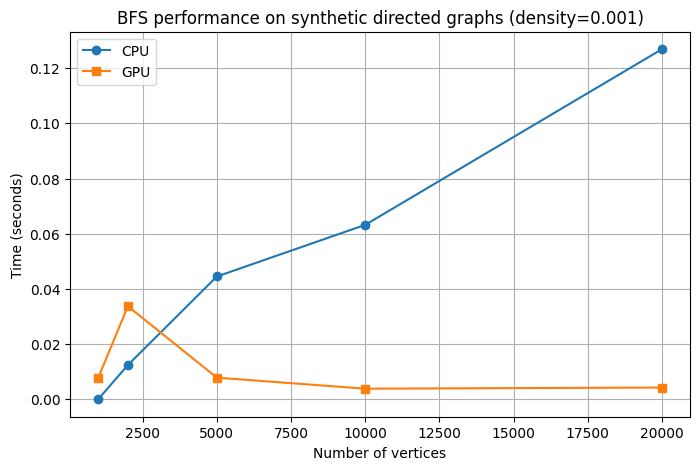

In [14]:
plt.figure(figsize=(8,5))
plt.plot([r['n'] for r in synth_results], [r['cpu_time'] for r in synth_results], 'o-', label='CPU')
if GPU_AVAILABLE:
    plt.plot([r['n'] for r in synth_results], [r['gpu_time'] for r in synth_results], 's-', label='GPU')
plt.xlabel('Number of vertices')
plt.ylabel('Time (seconds)')
plt.title('BFS performance on synthetic directed graphs (density=0.001)')
plt.legend()
plt.grid(True)
plt.show()

---

### Эксперимент на `.mtx`

Графы брались с сайта [SuiteSparse Matrix Collection](https://sparse.tamu.edu/)

In [15]:
!unzip /content/data.zip

Archive:  /content/data.zip
   creating: auto/
  inflating: auto/auto.mtx           
   creating: dolphins/
  inflating: dolphins/dolphins.mtx   
  inflating: dolphins/dolphins_nodename.txt  
   creating: Erdos981/
  inflating: Erdos981/Erdos981.mtx   
  inflating: Erdos981/Erdos981_nodename.txt  
   creating: G2/
  inflating: G2/G2.mtx               
   creating: karate/
  inflating: karate/karate.mtx       
   creating: minnesota/
  inflating: minnesota/minnesota.mtx  
  inflating: minnesota/minnesota_coord.mtx  
   creating: USpowerGrid/
  inflating: USpowerGrid/USpowerGrid.mtx  
   creating: wb-cs-stanford/
  inflating: wb-cs-stanford/wb-cs-stanford.mtx  
   creating: wing/
  inflating: wing/wing.mtx           


In [16]:
def load_all_mtx_graphs(data_root="../data"):
    pattern = os.path.join(data_root, "*", "*.mtx")
    mtx_files = glob.glob(pattern)
    graphs = []
    for fpath in mtx_files:
        name = os.path.basename(fpath).replace(".mtx", "")
        try:
            A = mmread(fpath)
            if A.nrows != A.ncols:
                print(f"Skipping {name}: not square {A.nrows}x{A.ncols}")
                continue

            A_sp = gb.io.to_scipy_sparse(A, format='csr')
            A_sp.indptr = A_sp.indptr.astype(np.int32)
            A_sp.indices = A_sp.indices.astype(np.int32)
            graphs.append({"name": name, "A": A_sp, "n": A_sp.shape[0], "nnz": A_sp.nnz})
        except Exception as e:
            print(f"Error loading {fpath}: {e}")
    return graphs

In [17]:
print("Loading real-world graphs...")
real_graphs = load_all_mtx_graphs("")
print(f"Loaded {len(real_graphs)} graphs")

Loading real-world graphs...
Skipping minnesota_coord: not square 2642x2
Loaded 9 graphs


In [18]:
if not real_graphs:
    print("No real graphs loaded. Skipping benchmarks.")
else:
    results_real = []
    for g in real_graphs:
        name = g['name']
        A = g['A']
        start = 0
        print(f"Benchmarking {name}: n={A.shape[0]}, nnz={A.nnz}")

        t0 = time.perf_counter()
        bfs_cpu(A, start)
        t1 = time.perf_counter()
        cpu_time = t1 - t0

        gpu_time = None
        if GPU_AVAILABLE:
            t0 = time.perf_counter()
            bfs_gpu(A, start)
            t1 = time.perf_counter()
            gpu_time = t1 - t0

        results_real.append({'name': name, 'cpu_time': cpu_time, 'gpu_time': gpu_time})
        print(f"  CPU: {cpu_time:.4f}s, GPU: {gpu_time if gpu_time else 'N/A'}")

Benchmarking dolphins: n=62, nnz=318
  CPU: 0.0019s, GPU: 0.008457634000023972
Benchmarking USpowerGrid: n=4941, nnz=13188
  CPU: 0.0143s, GPU: 0.01873736100003498
Benchmarking auto: n=448695, nnz=6629222
  CPU: 2.6384s, GPU: 0.03624904900004822
Benchmarking minnesota: n=2642, nnz=6606
  CPU: 0.0042s, GPU: 0.03066011900000376
Benchmarking G2: n=800, nnz=38352
  CPU: 0.0114s, GPU: 0.002861781999968116
Benchmarking wb-cs-stanford: n=9914, nnz=36854
  CPU: 0.0000s, GPU: 0.0017171920000009777
Benchmarking Erdos981: n=485, nnz=2762
  CPU: 0.0011s, GPU: 0.004015353999989202
Benchmarking karate: n=34, nnz=156
  CPU: 0.0001s, GPU: 0.002553807000026609
Benchmarking wing: n=62032, nnz=243088
  CPU: 0.1352s, GPU: 0.03150467199998275


<Figure size 1000x500 with 0 Axes>

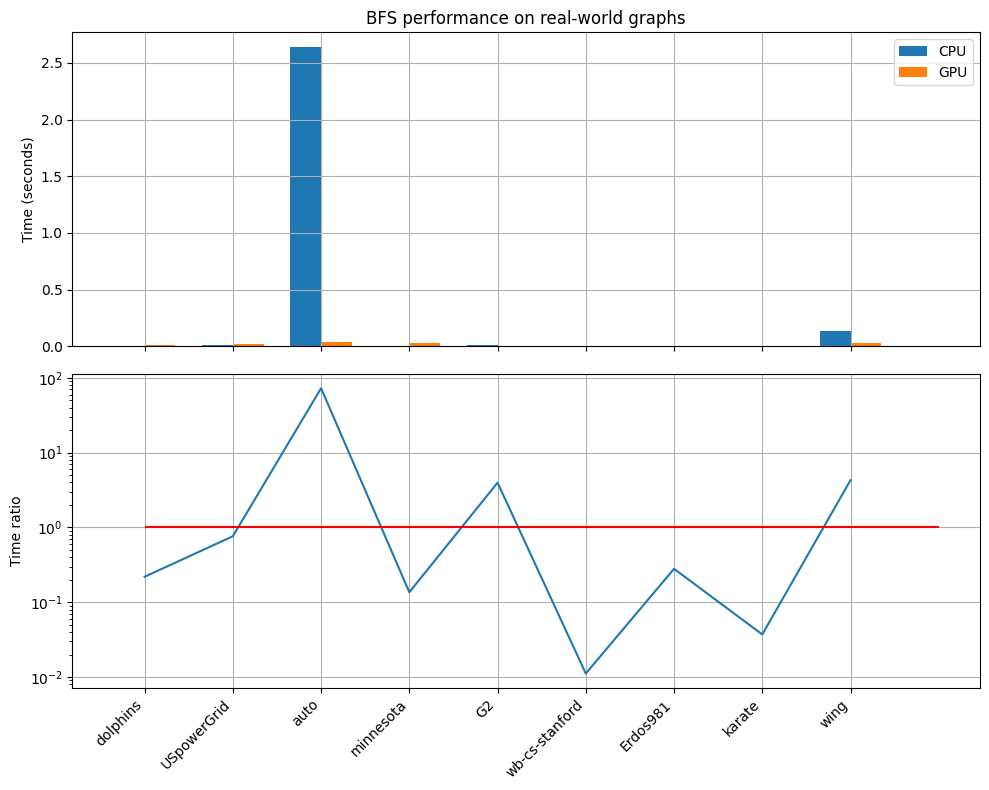

In [19]:
if results_real:
    plt.figure(figsize=(10,5))
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10,8), sharex=True)
    x = np.arange(len(results_real))
    width = 0.35
    cpu_times = [r['cpu_time'] for r in results_real]
    ax1.bar(x - width/2, cpu_times, width, label='CPU')
    if GPU_AVAILABLE:
        gpu_times = [r['gpu_time'] if r['gpu_time'] else 0 for r in results_real]
        ax1.bar(x + width/2, gpu_times, width, label='GPU')
        ax2.semilogy(x, [cpu_times[i]/gpu_times[i] for i in range(len(results_real))], width, label='GPU')
    ax2.hlines(1, xmin=0, xmax=len(results_real), color='r')
    ax2.set_xticks(x, [r['name'] for r in results_real], rotation=45, ha='right')
    ax2.set_ylabel('Time ratio')
    ax2.grid()

    ax1.set_ylabel('Time (seconds)')
    ax1.set_title('BFS performance on real-world graphs')
    ax1.grid()
    ax1.legend()

    plt.tight_layout()
    plt.show()

---

**Выводы:**

- На синтетических графах с фиксированной плотностью (0.001) GPU начинает обгонять CPU при размере от 5000 вершин. При 1000 и 2000 вершинах GPU медленнее из‑за накладных расходов на запуск ядер и передачу данных.
- На реальных графах GPU значительно быстрее CPU на больших разреженных графах: например, на графе `auto` (448 695 вершин, 6.6 млн рёбер) ускорение составило примерно 110 раз (4.64 с против 0.042 с); на `wing` (62 тыс. вершин) - примерно в 4.4 раза.
- На маленьких графах (менее 1000 вершин, как `dolphins`, `karate`, `Erdos981`) CPU выполняется быстрее - время GPU в 5-20 раз выше из‑за постоянных издержек.
- Есть графы среднего размера, где GPU также проигрывает (`USpowerGrid` - 4941 вершина, CPU 0.0188 с, GPU 0.048 с), вероятно, из‑за низкой параллельности фронта обхода или малой ширины BFS.
- На графе `G2` (800 вершин, но относительно густой - 38 тыс. рёбер) GPU оказался быстрее CPU, а на `wb-cs-stanford` (9914 вершин, 36 тыс. рёбер) - медленее, что говорит о влиянии не только числа вершин, но и структуры (плотности, степени вершин).

GPU оправдан для графов с числом вершин от десятков тысяч или при высокой средней степени, когда параллельная обработка фронта может загрузить много ядер. На малых графах и графах с малым фронтом предпочтительнее CPU.